In [90]:
import requests
import re
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.metrics import accuracy_score, log_loss
import matplotlib.pyplot as plt
import os
import requests
import io

In [91]:
#Parameters
Iterations = 2048 # number of iterations for Logistic Regression
random = 32 # random state for Logistic Regression

In [92]:
# Load Data
api_url = "https://api.github.com/repos/COMP3608-GROUP-9-PROJECT/COMP3608_PROJECT/contents/ProcessedData/processed_tournament_data.csv"

os.makedirs("processed", exist_ok=True)

response = requests.get(api_url)

if response.status_code == 200:
    file = response.json()
    download_url = file["download_url"]

    csv_data = requests.get(download_url).content
    df = pd.read_csv(io.BytesIO(csv_data))

    print("Loaded into DataFrame successfully")
else:
    raise Exception(f"Failed to access API: {response.status_code}")

df["ScoreDiff"] = df["T1AverageScore"] - df["T2AverageScore"]
df["FGM_diff"] = df["T1AverageFGM"] - df["T2AverageFGM"]
df["FGA_diff"] = df["T1AverageFGA"] - df["T2AverageFGA"]
df["FGM3_diff"] = df["T1AverageFGM3"] - df["T2AverageFGM3"]
df["FGA3_diff"] = df["T1AverageFGA3"] - df["T2AverageFGA3"]
df["FTM_diff"] = df["T1AverageFTM"] - df["T2AverageFTM"]
df["FTA_diff"] = df["T1AverageFTA"] - df["T2AverageFTA"]
df["OR_diff"] = df["T1AverageOR"] - df["T2AverageOR"]
df["DR_diff"] = df["T1AverageDR"] - df["T2AverageDR"]
df["Ast_diff"] = df["T1AverageAst"] - df["T2AverageAst"]
df["TO_diff"] = df["T1AverageTO"] - df["T2AverageTO"]
df["Stl_diff"] = df["T1AverageStl"] - df["T2AverageStl"]
df["Blk_diff"] = df["T1AverageBlk"] - df["T2AverageBlk"]
df["PF_diff"] = df["T1AveragePF"] - df["T2AveragePF"]

drop_cols = [col for col in df.columns if col.startswith("T1") or col.startswith("T2")]
df = df.drop(columns=drop_cols)

TARGET = "Win"

FEATURES = [col for col in df.columns if col not in ["Win", "Season", "PointDifference"]]

x = df[FEATURES]
y = df[TARGET]

groups = df["Season"]
seasons = df["Season"].unique()

gkf = GroupKFold(n_splits=len(seasons))


Loaded into DataFrame successfully


In [93]:
model = LogisticRegression(max_iter=Iterations, random_state=random)

cv_results = []
models = []

for season_idx, (train_index, test_index) in enumerate(gkf.split(x, y, groups)):
    test_season = groups.iloc[test_index].unique()[0]
    x_train, x_test = x.iloc[train_index], x.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    y_pred_prob = model.predict_proba(x_test)[:, 1]
    log_loss_score = log_loss(y_test, y_pred_prob)

    cv_results.append({
        "Season": test_season,
        "Accuracy": accuracy,
        "LogLoss": log_loss_score
    })

    models.append(model)

df_cv_results = pd.DataFrame(cv_results)
df_cv_results = df_cv_results.sort_values("Season")

for _, row in df_cv_results.iterrows():
    print(f"Season {int(row['Season'])}: Accuracy = {row['Accuracy']:.3f}, Log Loss = {row['LogLoss']:.3f}")

print(model.fit(x, y).score(x, y))

print(f"\nAverage Accuracy: {df_cv_results['Accuracy'].mean():.3f}")
print(f"Average Log Loss: {df_cv_results['LogLoss'].mean():.3f}")

Season 2003: Accuracy = 0.766, Log Loss = 0.491
Season 2004: Accuracy = 0.750, Log Loss = 0.525
Season 2005: Accuracy = 0.719, Log Loss = 0.551
Season 2006: Accuracy = 0.672, Log Loss = 0.567
Season 2007: Accuracy = 0.797, Log Loss = 0.425
Season 2008: Accuracy = 0.766, Log Loss = 0.488
Season 2009: Accuracy = 0.719, Log Loss = 0.525
Season 2010: Accuracy = 0.701, Log Loss = 0.518
Season 2011: Accuracy = 0.746, Log Loss = 0.499
Season 2012: Accuracy = 0.762, Log Loss = 0.492
Season 2013: Accuracy = 0.715, Log Loss = 0.538
Season 2014: Accuracy = 0.731, Log Loss = 0.524
Season 2015: Accuracy = 0.808, Log Loss = 0.455
Season 2016: Accuracy = 0.700, Log Loss = 0.554
Season 2017: Accuracy = 0.754, Log Loss = 0.518
Season 2018: Accuracy = 0.731, Log Loss = 0.535
Season 2019: Accuracy = 0.762, Log Loss = 0.468
Season 2021: Accuracy = 0.713, Log Loss = 0.549
Season 2022: Accuracy = 0.701, Log Loss = 0.577
Season 2023: Accuracy = 0.731, Log Loss = 0.554
Season 2024: Accuracy = 0.746, Log Loss 

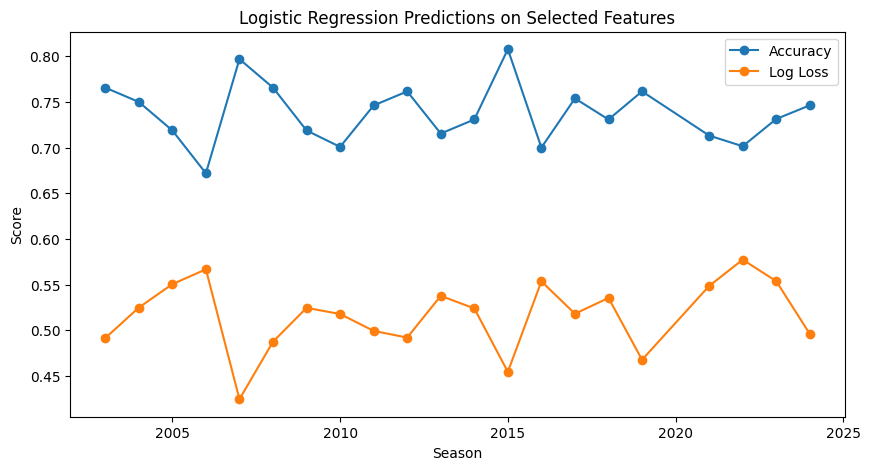

In [94]:
#Plot results to graph
plt.figure(figsize=(10, 5))
plt.plot(df_cv_results['Season'], df_cv_results['Accuracy'], marker='o', label='Accuracy')
plt.plot(df_cv_results['Season'], df_cv_results['LogLoss'], marker='o', label='Log Loss')
plt.xlabel("Season")
plt.ylabel("Score")
plt.title("Logistic Regression Predictions on Selected Features")
plt.legend()
plt.show()